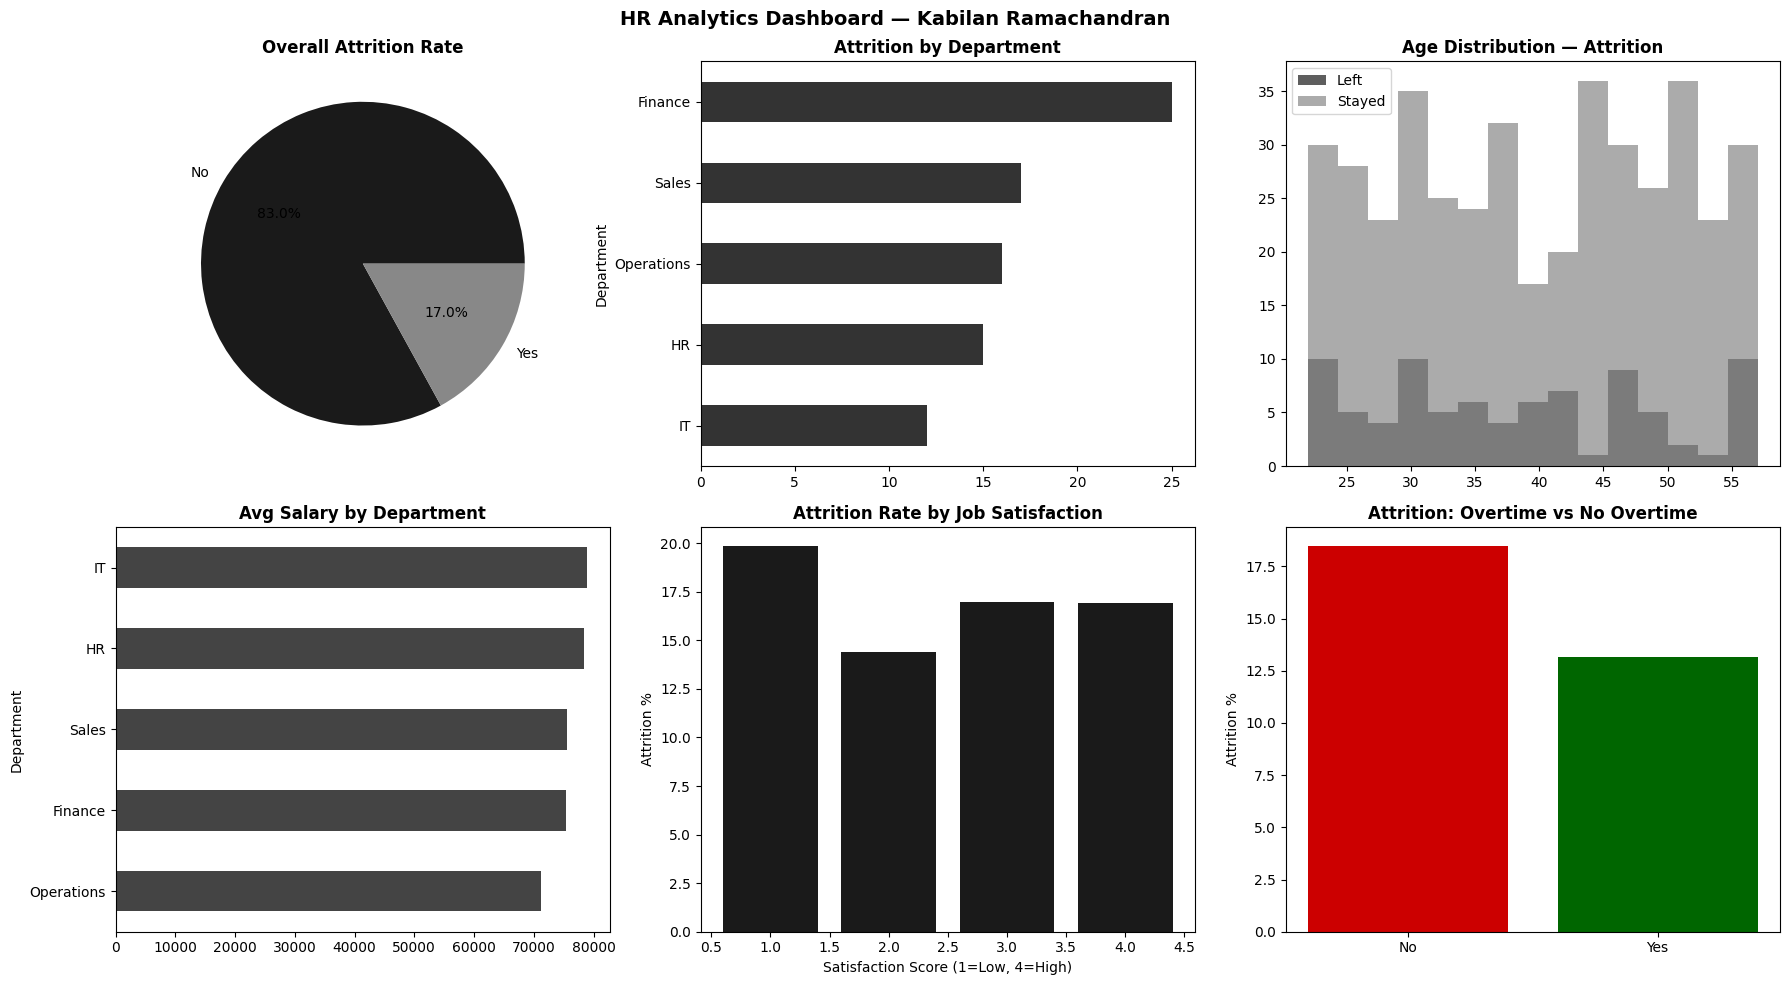

HR ANALYTICS INSIGHTS
Total Employees: 500
Attrition Rate: 17.0%
Avg Salary: £75,839
Highest Attrition Dept: Finance
Overtime Attrition: 13.1% vs 18.5% non-overtime
✅ HR Analytics Complete!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 500

df = pd.DataFrame({
    'EmployeeID': range(1, n+1),
    'Department': np.random.choice(['Sales','IT','HR','Finance','Operations'], n),
    'Age': np.random.randint(22, 58, n),
    'Salary': np.random.randint(30000, 120000, n),
    'YearsAtCompany': np.random.randint(1, 20, n),
    'JobSatisfaction': np.random.randint(1, 5, n),
    'Attrition': np.random.choice(['Yes','No'], n, p=[0.16, 0.84]),
    'Gender': np.random.choice(['Male','Female'], n),
    'OverTime': np.random.choice(['Yes','No'], n, p=[0.3, 0.7]),
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HR Analytics Dashboard — Kabilan Ramachandran', fontsize=14, fontweight='bold')

# Chart 1
attr = df['Attrition'].value_counts()
axes[0,0].pie(attr.values, labels=attr.index, autopct='%1.1f%%', colors=['#1A1A1A','#888888'])
axes[0,0].set_title('Overall Attrition Rate', fontweight='bold')

# Chart 2
dept_attr = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').sum()).sort_values()
dept_attr.plot(kind='barh', ax=axes[0,1], color='#333333')
axes[0,1].set_title('Attrition by Department', fontweight='bold')

# Chart 3
axes[0,2].hist(df[df['Attrition']=='Yes']['Age'], bins=15, color='#1A1A1A', alpha=0.7, label='Left')
axes[0,2].hist(df[df['Attrition']=='No']['Age'], bins=15, color='#888888', alpha=0.7, label='Stayed')
axes[0,2].set_title('Age Distribution — Attrition', fontweight='bold')
axes[0,2].legend()

# Chart 4
dept_sal = df.groupby('Department')['Salary'].mean().sort_values()
dept_sal.plot(kind='barh', ax=axes[1,0], color='#444444')
axes[1,0].set_title('Avg Salary by Department', fontweight='bold')

# Chart 5
sat_attr = df.groupby('JobSatisfaction')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
axes[1,1].bar(sat_attr.index, sat_attr.values, color='#1A1A1A')
axes[1,1].set_title('Attrition Rate by Job Satisfaction', fontweight='bold')
axes[1,1].set_xlabel('Satisfaction Score (1=Low, 4=High)')
axes[1,1].set_ylabel('Attrition %')

# Chart 6
ot_attr = df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
axes[1,2].bar(ot_attr.index, ot_attr.values, color=['#CC0000','#006600'])
axes[1,2].set_title('Attrition: Overtime vs No Overtime', fontweight='bold')
axes[1,2].set_ylabel('Attrition %')

plt.tight_layout()
plt.savefig('hr_analytics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("="*50)
print("HR ANALYTICS INSIGHTS")
print("="*50)
print(f"Total Employees: {len(df):,}")
print(f"Attrition Rate: {(df['Attrition']=='Yes').mean()*100:.1f}%")
print(f"Avg Salary: £{df['Salary'].mean():,.0f}")
print(f"Highest Attrition Dept: {dept_attr.index[-1]}")
print(f"Overtime Attrition: {ot_attr['Yes']:.1f}% vs {ot_attr['No']:.1f}% non-overtime")
print("✅ HR Analytics Complete!")